# Experiment 3 – Random-dot motion: GOAL model fit (Gamma prior)

Fits the Goal-oriented Asymmetric Likelihood (GOAL) model separately to each goal frame.

- **Data:** `RDMFrame_FullProlificData_CoherenceControl_Apr2021.csv`; frames `Frame == 1` (High Motion) and `Frame == 2` (Low Motion) (evidence = number of dots moving left/right (dot number x coherence)).
- **Model:** Gamma priors on the belief SDs, Gamma(α = 6, β = 1.2) – robustness check (Figure S3). Means of the low/high belief distributions are fixed from a median split of the evidence; choice and confidence (with RT) are observed.
- **Fitting:** even-numbered trials, PyMC NUTS, 4 chains × 4000 draws (1000 tuning).
- **Output:** posterior traces saved as `.nc` files, used by `Figure_exp1-4_ModelFit_GammaPrior.ipynb` to simulate held-out trials and make the figures.

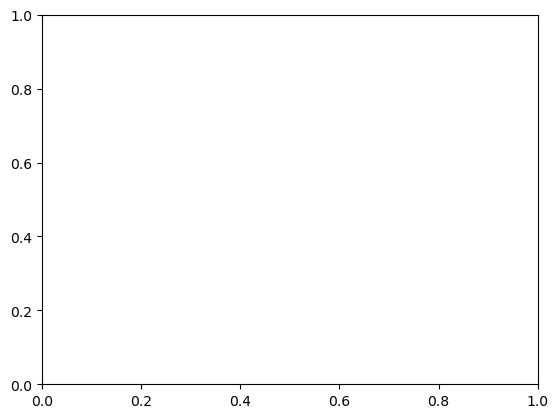

In [1]:
import pymc as pm
import pandas as pd
import arviz as az
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
from scipy import stats
import  pytensor.tensor as pt

import functionsSims as fs

In [2]:
def mainLoad(data_part_all0):
    # Prepare one frame: z-score within participant, split even/odd trials,
    # extract model inputs and plot the evidence/confidence distributions

    # z-score values
    data_part_all0['LDotNum'] = data_part_all0['Dot Num']*data_part_all0['LCoh']
    data_part_all0['RDotNum'] = data_part_all0['Dot Num']*data_part_all0['RCoh']
    data_part_all0['AbsDDotNum'] = np.abs(data_part_all0['RDotNum'] - data_part_all0['LDotNum'])
    data_part_all0['zLDotNum'] = fs.zscore1(data_part_all0,'LDotNum', 'Part')
    data_part_all0['zRDotNum'] = fs.zscore1(data_part_all0,'RDotNum', 'Part')
    data_part_all0['zAbsDDotNum'] = fs.zscore1(data_part_all0,'AbsDDotNum', 'Part')

    data_part_all0['zLCoh'] = fs.zscore1(data_part_all0,'LCoh', 'Part')
    data_part_all0['zRCoh'] = fs.zscore1(data_part_all0,'RCoh', 'Part')
    data_part_all0['zConf'] = fs.zscore1(data_part_all0,'Confidence', 'Part')
    data_part_all0['zDotNum'] = fs.zscore1(data_part_all0,'Dot Num', 'Part')
    data_part_all0['zRT'] = fs.zscore1(data_part_all0,'Reaction Time', 'Part')

    # estimate choice and confidence compound
    data_part_all0['choiceConf'] = data_part_all0.Conf * (2*data_part_all0.Choice-1) # second term is to transform choice to left : -1; right: +1
    data_part_all0['zChoiceConf'] = fs.zscore1(data_part_all0,'choiceConf', 'Part')

    # Split trials: model fitted to even trials, odd trials kept as test set
    data_part_all = data_part_all0.loc[data_part_all0.TrialNN%2 == 0]
    data_part_all_test = data_part_all0.loc[data_part_all0.TrialNN%2 == 1]

    # load input 
    val_a = data_part_all.zLDotNum.values.copy()
    val_b = data_part_all.zRDotNum.values.copy()

    abs_d_dots = data_part_all.zAbsDDotNum.values.copy()

    chosenByPart = data_part_all.Choice.values
    rtByPart = data_part_all.zRT.values

    # generate all values to be sorted to generate high and low value distributions
    value_sort = data_part_all.copy()
    value_sort = value_sort.zLDotNum.values

    confByPart = data_part_all.zConf.values
    choiceConfByPart = data_part_all.zChoiceConf.values

    confNormByPart = fs.norm01(data_part_all,'zConf','Part')

    delta_og = data_part_all.zLDotNum
    delta_og.hist()
    plt.title(r"Distribution of values from participant")
    print('mean of the value distribution: ' + str(val_a.mean()))
    print('std of the value distribution: ' + str(val_a.std()))
    plt.show()

    val_og = data_part_all.zLDotNum
    conf_og = data_part_all.zConf
    conf_og.hist()
    plt.title(r"Distribution of confidence from participant (zScored)")
    print('mean of the confidence distribution: ' + str(conf_og.mean()))
    print('std of the confidence distribution: ' + str(conf_og.std()))
    plt.show()

    choiceConf_og = data_part_all0['Conf'] 
    plt.hist(choiceConf_og)
    plt.title(r"Distribution of zscored confidence from participant")
    print('mean : ' + str(np.mean(choiceConf_og)))
    print('std  : ' + str(np.std(choiceConf_og)))
    plt.show()

    choiceConf_og = confNormByPart
    plt.hist(choiceConf_og)
    plt.title(r"Distribution of normalized 0-1 confidence from participant")
    print('mean : ' + str(np.mean(choiceConf_og)))
    print('std  : ' + str(np.std(choiceConf_og)))
    plt.show()

    # Means of the low/high evidence distributions from a median split of the evidence (Figure S2)
    lvalParam, hvalParam = fs.split_values_highLow (value_sort)

    return val_a, val_b, chosenByPart, rtByPart, lvalParam, hvalParam, confByPart, confNormByPart, choiceConfByPart, data_part_all, data_part_all_test   

In [6]:
data = pd.read_csv('../Data/SepulvedaNew/RDMFrame_FullProlificData_CoherenceControl_Apr2021.csv')

# Low Motion frame (`Frame == 2`)

mean of the value distribution: 0.0008341445040587454
std of the value distribution: 1.0048272451993063


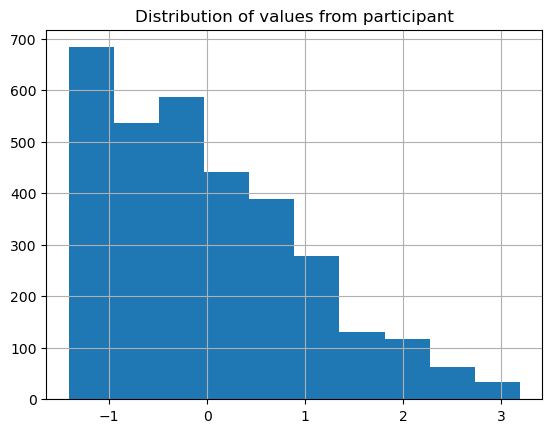

mean of the confidence distribution: -0.01525087318373981
std of the confidence distribution: 1.0030152450128798


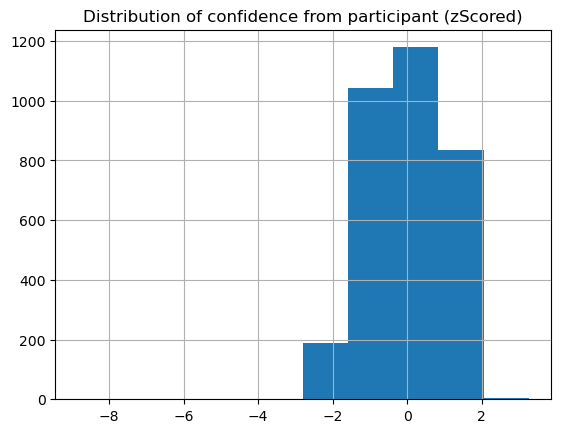

mean : 53.99014778325123
std  : 2.531980470168129


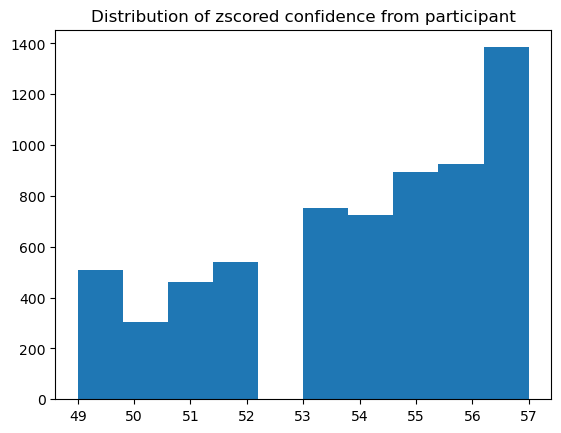

mean : 0.6099308661463357
std  : 0.3191330835283078


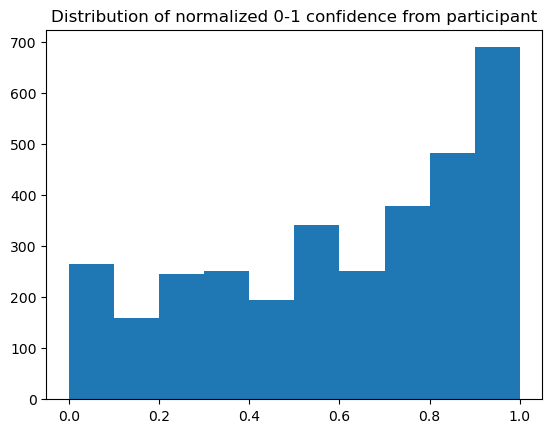

mean values -> high: 0.7809324876658311 ,  low:-0.8052776344183324
stdev values -> high: 0.7809324876658311 ,  low:0.33118162372557486
low values distribution: mean:-0.8052776344183324, var:0.33118162372557486
high values distribution: mean:0.8075328097864923, var:0.7809324876658311


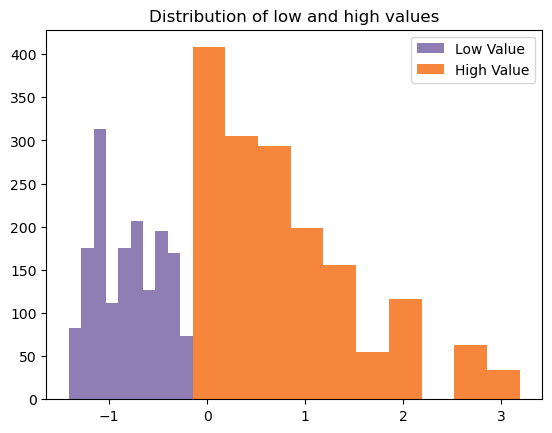

In [7]:
data_part_all0 =  data.loc[data.Frame == 2] # Low Motion frame

val_a, val_b, chosenByPart, rtByPart, lvalParam, hvalParam, confByPart, confNormByPart, choiceConfByPart, data_part_all, data_part_all_test      = mainLoad(data_part_all0)

In [8]:
n_trials = len (val_a)
RANDOM_SEED = 58
rng = np.random.default_rng(RANDOM_SEED)

In [9]:
# Fixed means of the low (mu[0]) and high (mu[1]) evidence belief distributions
mu = [lvalParam[0],hvalParam[0]]
    
with pm.Model() as model_peb2:
    # Free parameters: SDs of the belief distributions (sigmaBel1: low-evidence, sigmaBel2: high-evidence category)
    sigmaGen1 = pm.Gamma('sigmaBel1', alpha=6, beta=1.2)  # mean ≈5, mode away from 0
    sigmaGen2 = pm.Gamma('sigmaBel2', alpha=6, beta=1.2)

    # Observed (z-scored) evidence for the left/right option on each trial
    lVal = pm.Normal('lVal', mu = val_a, sigma = 0.001 , shape = n_trials)
    rVal = pm.Normal('rVal', mu = val_b, sigma = 0.001  , shape = n_trials)

    # Log-likelihood ratio that <right, left> = <high, low> rather than <low, high> evidence
    # (Gaussian belief distributions with means mu and SDs sigmaGen1/sigmaGen2)
    LLR = pm.Deterministic('LLR',  pt.log(1/(sigmaGen2 * pt.sqrt(2 * np.pi))*pt.exp(-pt.power(rVal - mu[1] , 2.) / (2 * pt.power(sigmaGen2, 2.)))) - 
                                    pt.log(1/(sigmaGen1 * pt.sqrt(2 * np.pi))*pt.exp(-pt.power(rVal - mu[0] , 2.) / (2 * pt.power(sigmaGen1, 2.)))) + 
                                    pt.log(1/(sigmaGen1 * pt.sqrt(2 * np.pi))*pt.exp(-pt.power(lVal - mu[0] , 2.) / (2 * pt.power(sigmaGen1, 2.)))) -
                                    pt.log(1/(sigmaGen2 * pt.sqrt(2 * np.pi))*pt.exp(-pt.power(lVal - mu[1] , 2.) / (2 * pt.power(sigmaGen2, 2.))))  )

    # Choice: logistic function of the LLR; beta scales its influence (prior precision tau = 0.001)
    beta = pm.Normal("beta", mu=0, tau=0.001, testval=0)
    p = pm.Deterministic("p", 1.0/(1. + pt.exp(beta*LLR) ))    
    
    choice = pm.Bernoulli("choice", p, observed=chosenByPart)

    # Confidence: logistic function of |LLR| and RT, weighted by betaConf and betaRT
    betaConf = pm.Normal("betaConf", mu=0, tau=0.001, testval=0)      
    betaRT = pm.Normal("betaRT", mu=0, tau=0.001, testval=0)
    
    conf = pm.Deterministic("conf",1.0/(1. + pt.exp(betaConf*pt.abs(LLR) + betaRT*rtByPart)) )

    # Reported confidence (normalised 0-1 per participant) with small noise (sigma = 0.025)
    confRep = pm.Normal('confReport',mu = conf, sigma=0.025, observed=confNormByPart)  

# MCMC settings: 4 chains x 4000 draws (NUTS), 1000 tuning steps
nsample = 4000
nchains = 4
    

In [10]:
with model_peb2:
    
    # Prior predictive samples, then posterior sampling with NUTS
    trace2 = pm.sample_prior_predictive( random_seed=rng)
    trace2.extend(pm.sample(nsample, cores=4,tune=1000, chains=nchains, return_inferencedata=True))

Sampling: [beta, betaConf, betaRT, choice, confReport, lVal, rVal, sigmaBel1, sigmaBel2]
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigmaBel1, sigmaBel2, lVal, rVal, beta, betaConf, betaRT]


Sampling 4 chains for 1_000 tune and 4_000 draw iterations (4_000 + 16_000 draws total) took 6255 seconds.


In [14]:
# Save posterior (loaded by Figure_exp1-4_ModelFit_*.ipynb)
trace2.to_netcdf("sample_exp3_LowMotion_gammaPrior.nc")

'sample_exp3_LowMotion_gammaPrior.nc'

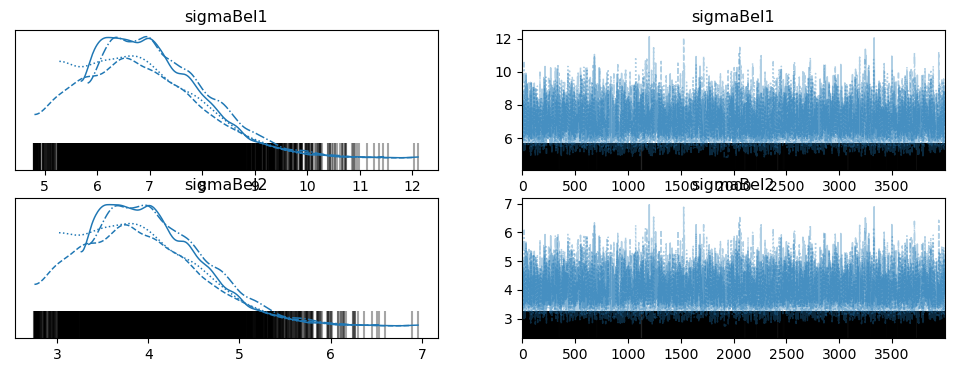

In [15]:
# Convergence check: trace plots
az.plot_trace(trace2, var_names=[ 'sigmaBel1','sigmaBel2']);

In [16]:
# Convergence check: Gelman-Rubin R-hat
rhats_params = az.rhat(trace2, method="folded")
rhats_params

<xarray.Dataset>
Dimensions:     (lVal_dim_0: 3258, rVal_dim_0: 3258, LLR_dim_0: 3258,
                 p_dim_0: 3258, conf_dim_0: 3258)
Coordinates:
  * lVal_dim_0  (lVal_dim_0) int64 0 1 2 3 4 5 ... 3252 3253 3254 3255 3256 3257
  * rVal_dim_0  (rVal_dim_0) int64 0 1 2 3 4 5 ... 3252 3253 3254 3255 3256 3257
  * LLR_dim_0   (LLR_dim_0) int64 0 1 2 3 4 5 ... 3252 3253 3254 3255 3256 3257
  * p_dim_0     (p_dim_0) int64 0 1 2 3 4 5 6 ... 3252 3253 3254 3255 3256 3257
  * conf_dim_0  (conf_dim_0) int64 0 1 2 3 4 5 ... 3252 3253 3254 3255 3256 3257
Data variables:
    lVal        (lVal_dim_0) float64 1.0 1.001 1.0 1.001 ... 1.0 1.001 1.0 1.001
    rVal        (rVal_dim_0) float64 1.001 1.001 1.0 1.001 ... 1.0 1.001 1.0
    beta        float64 1.005
    betaConf    float64 1.005
    betaRT      float64 1.0
    sigmaBel1   float64 1.008
    sigmaBel2   float64 1.008
    LLR         (LLR_dim_0) float64 1.022 1.022 1.022 ... 1.022 1.022 1.022
    p           (p_dim_0) float64 1.0 1.0 1.0 1.001 1.001 ... 1.0 1.0 1.0 1.0
    conf        (conf_dim_0) float64 1.001 1.001 0.9998 ... 1.0 0.9999 1.0

Compare: Mean1 = 7.018594731050083; Mean2 = 4.02314898721926; [mean1 - mean2] =  2.995445743830823; t =  843.43 ; p-value =0.0


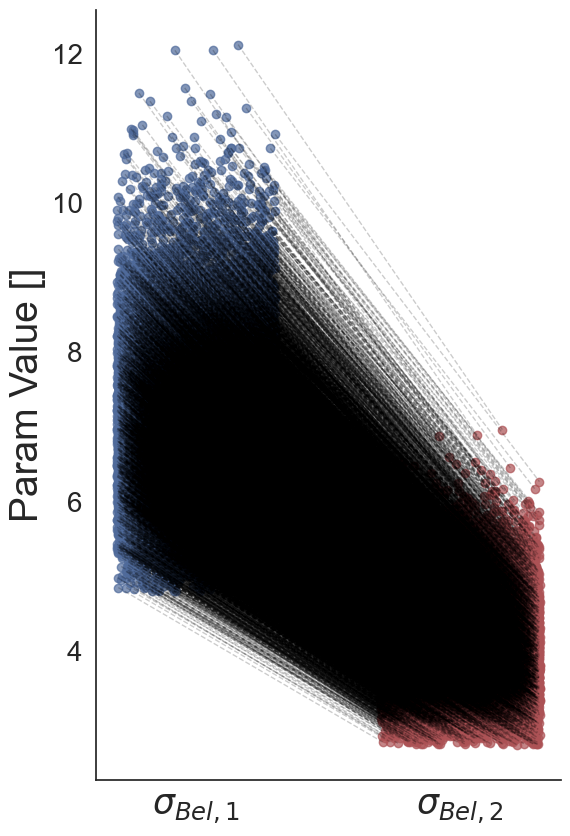

In [17]:
# Posterior of sigmaBel1 (low) vs sigmaBel2 (high)
fs.ttestsPlot(trace2.posterior['sigmaBel1'].values.flatten(), trace2.posterior['sigmaBel2'].values.flatten(),'#4F6A9A','#AC5255',"$\sigma_{Bel,1}$","$\sigma_{Bel,2}$",title = 'Param Value []')

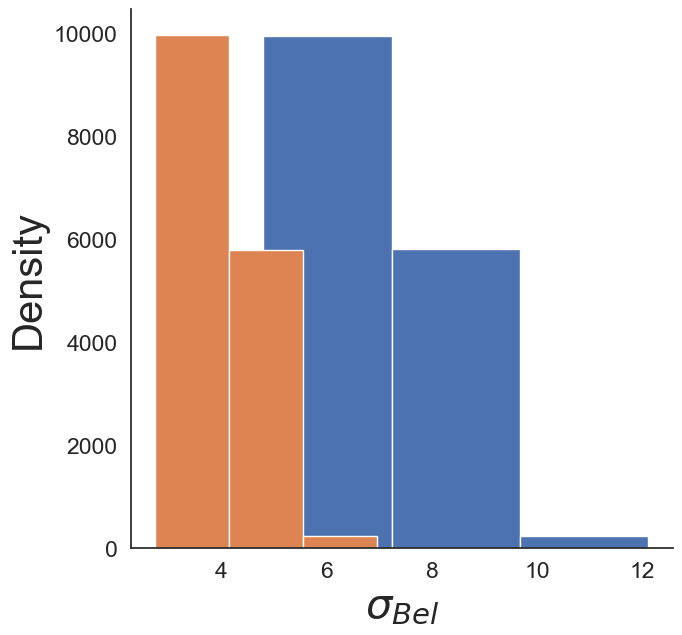

Proportion density above 0 : 0.0
Proportion density below 0 : 1.0
Mean sigmaBel1:7.018594731050083; SD sigmaBel1:1.0518366770895644
Mean sigmaBel2:4.02314898721926; SD sigmaBel2:0.6029593930955919
Delta sigmaBel mean:-2.9954457438308224; SD:0.4492211996531277


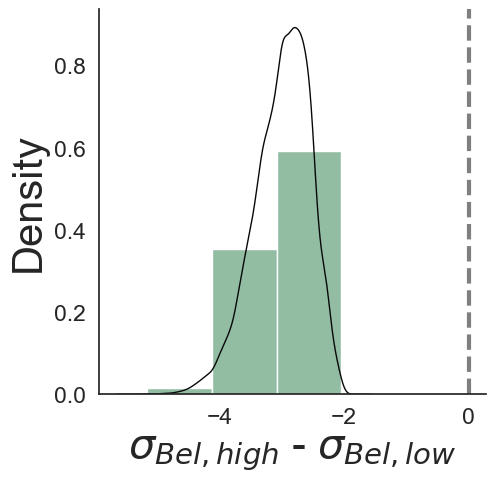

In [18]:
# Posterior of the belief-variance asymmetry (sigmaBel,high - sigmaBel,low)
fs.plotSigmaBelDensity(trace2, colorP = '#92BDA3',n_bins = 3,figName = '')

# High Motion frame (`Frame == 1`)

mean of the value distribution: -0.009961488993498618
std of the value distribution: 0.9926127261549635


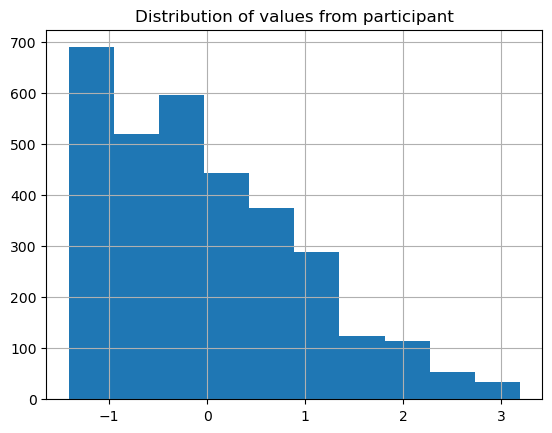

mean of the confidence distribution: -0.005608760027675311
std of the confidence distribution: 1.0073098403847114


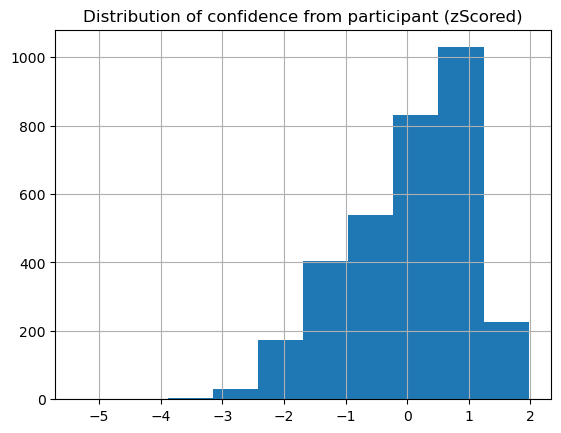

mean : 54.566964285714285
std  : 2.1849825604258


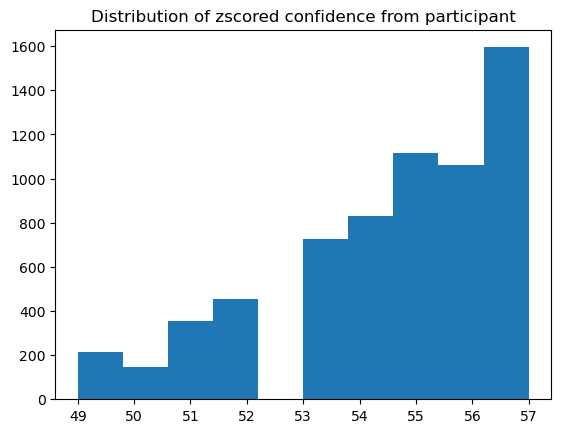

mean : 0.6835642224771317
std  : 0.2806689109773922


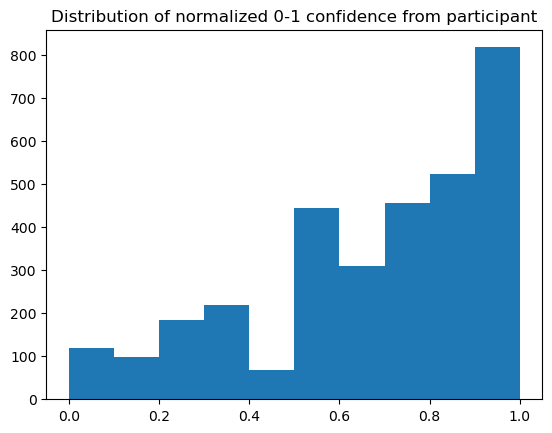

mean values -> high: 0.7858110502615361 ,  low: -0.8057340282485334
stdev values -> high: 0.7697027874908746 ,  low: 0.3340805272887706
low values distribution: mean:-0.8057340282485334, var:0.3340805272887706
high values distribution: mean:0.7858110502615361, var:0.7697027874908746


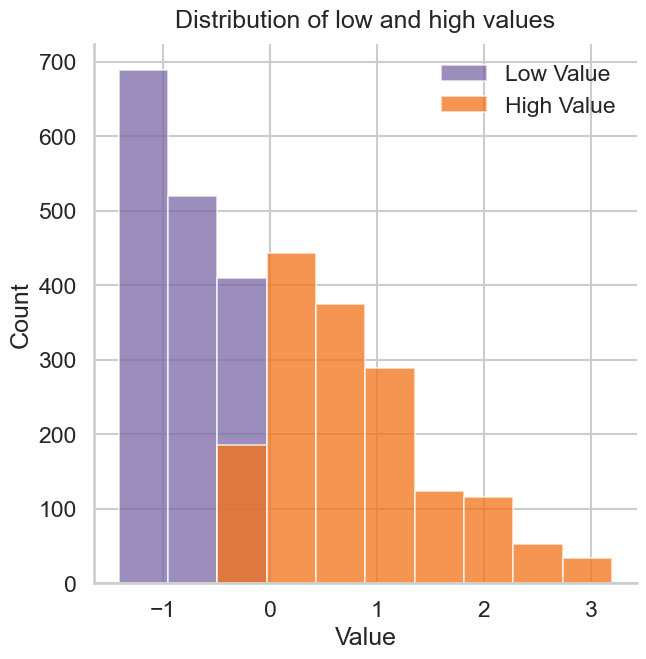

In [7]:
data_part_all0 =  data.loc[data.Frame == 1] # High Motion frame

val_a, val_b, chosenByPart, rtByPart, lvalParam, hvalParam, confByPart, confNormByPart, choiceConfByPart, data_part_all, data_part_all_test      = mainLoad(data_part_all0)

In [8]:
n_trials = len (val_a)
RANDOM_SEED = 1
rng = np.random.default_rng(RANDOM_SEED)

# Fixed means of the low (mu[0]) and high (mu[1]) evidence belief distributions
mu = [lvalParam[0],hvalParam[0]]
    
with pm.Model() as model_peb2:

    # Free parameters: SDs of the belief distributions (sigmaBel1: low-evidence, sigmaBel2: high-evidence category)
    sigmaGen1 = pm.Gamma('sigmaBel1', alpha=6, beta=1.2)  # mean ≈5, mode away from 0
    sigmaGen2 = pm.Gamma('sigmaBel2', alpha=6, beta=1.2)

    # Observed (z-scored) evidence for the left/right option on each trial
    lVal = pm.Normal('lVal', mu = val_a, sigma = 0.001 , shape = n_trials)
    rVal = pm.Normal('rVal', mu = val_b, sigma = 0.001  , shape = n_trials)

    # Log-likelihood ratio that <right, left> = <high, low> rather than <low, high> evidence
    # (Gaussian belief distributions with means mu and SDs sigmaGen1/sigmaGen2)
    LLR = pm.Deterministic('LLR',  pt.log(1/(sigmaGen2 * pt.sqrt(2 * np.pi))*pt.exp(-pt.power(rVal - mu[1] , 2.) / (2 * pt.power(sigmaGen2, 2.)))) - 
                                    pt.log(1/(sigmaGen1 * pt.sqrt(2 * np.pi))*pt.exp(-pt.power(rVal - mu[0] , 2.) / (2 * pt.power(sigmaGen1, 2.)))) + 
                                    pt.log(1/(sigmaGen1 * pt.sqrt(2 * np.pi))*pt.exp(-pt.power(lVal - mu[0] , 2.) / (2 * pt.power(sigmaGen1, 2.)))) -
                                    pt.log(1/(sigmaGen2 * pt.sqrt(2 * np.pi))*pt.exp(-pt.power(lVal - mu[1] , 2.) / (2 * pt.power(sigmaGen2, 2.))))  )

    # Choice: logistic function of the LLR; beta scales its influence (prior precision tau = 0.001)
    beta = pm.Normal("beta", mu=0, tau=0.001, testval=0)
    p = pm.Deterministic("p", 1.0/(1. + pt.exp(beta*LLR) ))    
    
    choice = pm.Bernoulli("choice", p, observed=chosenByPart)

    # Confidence: logistic function of |LLR| and RT, weighted by betaConf and betaRT
    betaConf = pm.Normal("betaConf", mu=0, tau=0.001, testval=0)      
    betaRT = pm.Normal("betaRT", mu=0, tau=0.001, testval=0)
    
    conf = pm.Deterministic("conf",1.0/(1. + pt.exp(betaConf*pt.abs(LLR) + betaRT*rtByPart)) )

    # Reported confidence (normalised 0-1 per participant) with small noise (sigma = 0.025)
    confRep = pm.Normal('confReport',mu = conf, sigma=0.025, observed=confNormByPart)  

# MCMC settings: 4 chains x 4000 draws (NUTS), 1000 tuning steps
nsample = 4000
nchains = 4
    

In [9]:
with model_peb2:
    
    # Prior predictive samples, then posterior sampling with NUTS
    trace2 = pm.sample_prior_predictive( random_seed=rng)
    trace2.extend(pm.sample(nsample, cores=4,tune=1000, chains=nchains, return_inferencedata=True))

Sampling: [beta, betaConf, betaRT, choice, confReport, lVal, rVal, sigmaBel1, sigmaBel2]
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigmaBel1, sigmaBel2, lVal, rVal, beta, betaConf, betaRT]


Sampling 4 chains for 1_000 tune and 4_000 draw iterations (4_000 + 16_000 draws total) took 4710 seconds.


In [12]:
# Save posterior (loaded by Figure_exp1-4_ModelFit_*.ipynb)
trace2.to_netcdf("sample_exp3_HighMotion_gammaPrior_v2.nc")

'sample_exp3_HighMotion_gammaPrior_v2.nc'

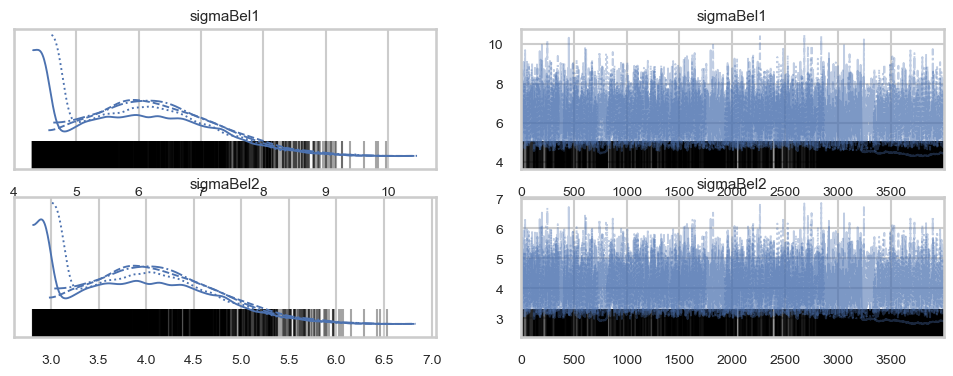

In [13]:
# Convergence check: trace plots
az.plot_trace(trace2, var_names=['sigmaBel1', 'sigmaBel2']);

In [14]:
# Convergence check: Gelman-Rubin R-hat
rhats_params = az.rhat(trace2, method="folded")
rhats_params

<xarray.Dataset>
Dimensions:     (lVal_dim_0: 3238, rVal_dim_0: 3238, LLR_dim_0: 3238,
                 p_dim_0: 3238, conf_dim_0: 3238)
Coordinates:
  * lVal_dim_0  (lVal_dim_0) int64 0 1 2 3 4 5 ... 3232 3233 3234 3235 3236 3237
  * rVal_dim_0  (rVal_dim_0) int64 0 1 2 3 4 5 ... 3232 3233 3234 3235 3236 3237
  * LLR_dim_0   (LLR_dim_0) int64 0 1 2 3 4 5 ... 3232 3233 3234 3235 3236 3237
  * p_dim_0     (p_dim_0) int64 0 1 2 3 4 5 6 ... 3232 3233 3234 3235 3236 3237
  * conf_dim_0  (conf_dim_0) int64 0 1 2 3 4 5 ... 3232 3233 3234 3235 3236 3237
Data variables:
    lVal        (lVal_dim_0) float64 1.014 1.009 1.012 ... 1.005 1.017 1.011
    rVal        (rVal_dim_0) float64 1.001 1.011 1.014 ... 1.017 1.01 1.036
    beta        float64 1.011
    betaConf    float64 1.013
    betaRT      float64 1.023
    sigmaBel1   float64 1.02
    sigmaBel2   float64 1.02
    LLR         (LLR_dim_0) float64 1.052 1.052 1.052 ... 1.052 1.052 1.052
    p           (p_dim_0) float64 1.002 1.002 1.002 1.002 ... 1.002 1.002 1.002
    conf        (conf_dim_0) float64 1.001 1.001 1.009 ... 0.9998 1.007 1.0

Compare: Mean1 = 6.1443485054639995; Mean2 = 4.021800046700576; [mean1 - mean2] =  2.122548458763424; t =  726.32 ; p-value =0.0


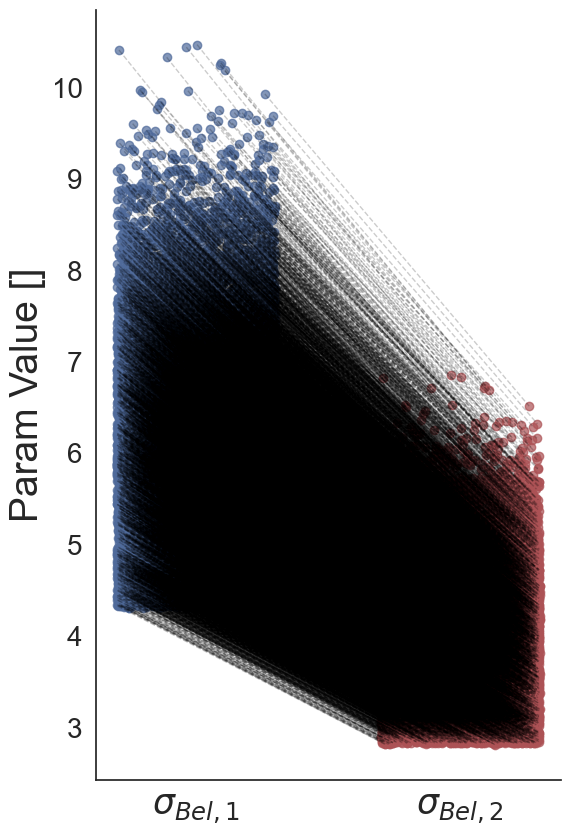

In [15]:
# Posterior of sigmaBel1 (low) vs sigmaBel2 (high)
fs.ttestsPlot(trace2.posterior['sigmaBel1'].values.flatten(), trace2.posterior['sigmaBel2'].values.flatten(),'#4F6A9A','#AC5255',"$\sigma_{Bel,1}$","$\sigma_{Bel,2}$",title = 'Param Value []')

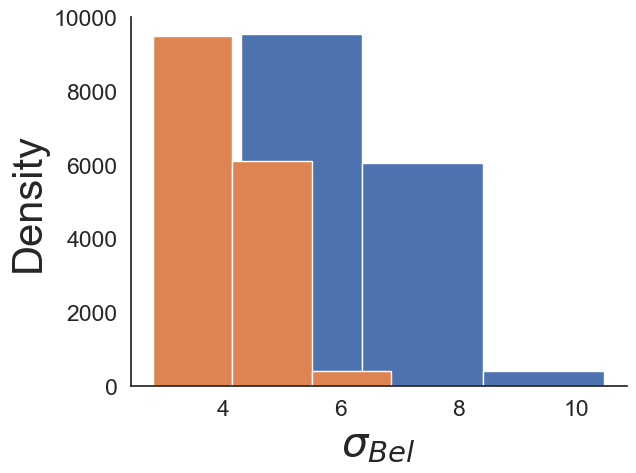

Proportion density above 0 : 0.0
Proportion density below 0 : 1.0
Mean sigmaBel1:6.1443485054639995; SD sigmaBel1:1.068837314203509
Mean sigmaBel2:4.021800046700576; SD sigmaBel2:0.6994855394296858
Delta sigmaBel mean:-2.1225484587634247; SD:0.3696366019742728


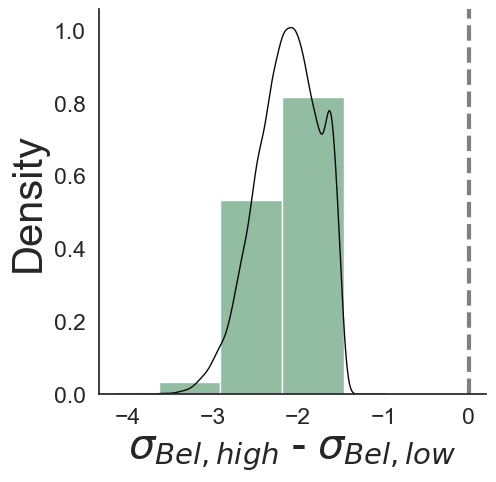

In [16]:
# Posterior of the belief-variance asymmetry (sigmaBel,high - sigmaBel,low)
fs.plotSigmaBelDensity(trace2, colorP = '#92BDA3',n_bins = 3,figName = '')

# Comparison of the belief-variance asymmetry between frames

In [23]:
trace_high = az.from_netcdf("sample_exp3_HighMotion_gammaPrior_v2.nc")
trace_low = az.from_netcdf("sample_exp3_LowMotion_gammaPrior.nc")

Text(0.5, 0, '$\\sigma_{Bel,high}$ - $\\sigma_{Bel,low}$')

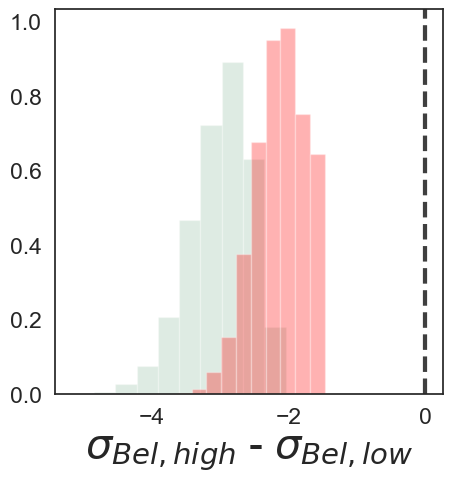

In [24]:
    sBel1 = trace_low.posterior['sigmaBel1'].values.flatten()
    sBel2 = trace_low.posterior['sigmaBel2'].values.flatten()
    fig, ax = plt.subplots(figsize=(5,5))
    var1_low = sBel2- sBel1
    plt.hist(var1_low, bins=10, color = '#92BDA3', alpha = .3,density=True )
    plt.axvline(0, color='black', lw=3, alpha=0.5,linestyle="--")
    plt.xlabel("$\sigma_{Bel,high}$ - $\sigma_{Bel,low}$",fontsize=30)

    sBel1 = trace_high.posterior['sigmaBel1'].values.flatten()
    sBel2 = trace_high.posterior['sigmaBel2'].values.flatten()
    var1_high = sBel2- sBel1
    plt.hist(var1_high, bins=10, color = 'red',density=True, alpha = 0.3 )
    plt.axvline(0, color='black', lw=3, alpha=0.5,linestyle="--")
    plt.xlabel("$\sigma_{Bel,high}$ - $\sigma_{Bel,low}$",fontsize=30)

In [25]:
# t-test independent between two samples
test_stat, p_value = stats.ttest_ind(var1_low, var1_high)

print("Test Statistic:", test_stat)
print("P-Value:", p_value)

Test Statistic: -189.7905372118453
P-Value: 0.0


In [26]:
# estimate significant differences between the two distributions using permutation analysis

import numpy as np
from scipy.stats import permutation_test
def statistic(x, y, axis):
    return np.mean(x, axis=axis) - np.mean(y, axis=axis)

res = permutation_test((var1_high, var1_low), statistic, vectorized=True,n_resamples=10000, alternative='less')

In [28]:
res

PermutationTestResult(statistic=0.8728972850673977, pvalue=1.0, null_distribution=array([-0.00769625, -0.00455326,  0.0008248 , ..., -0.01383036,
       -0.00105768, -0.0015805 ]))